In [1]:
print("Everything is okay!")

Everything is okay!


In [2]:
# Import libraries

import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from collections import Counter

In [ ]:
# Read the dataset

wiki_df = pd.read_csv('temp/data_wiki.csv')

In [4]:
# funtion to visualize the top 5 rows, last 5 rows and random 5 rows of the dataset

def display_samples(df):
    
    print("Top 5 rows: \n", df.head())
    print("\nLast 5 rows: \n", df.tail())
    print("\nRandom 5 rows: \n", df.sample(5))


In [5]:
display_samples(wiki_df)

Top 5 rows: 
    Unnamed: 0                                               text
0           1  Anovo\n\nAnovo (formerly A Novo) is a computer...
1           2  Battery indicator\n\nA battery indicator (also...
2           3  Bob Pease\n\nRobert Allen Pease (August 22, 19...
3           4  CAVNET\n\nCAVNET was a secure military forum w...
4           5  CLidar\n\nThe CLidar is a scientific instrumen...

Last 5 rows: 
        Unnamed: 0                                               text
10854       10855  Soundcast\n\nSoundcast LLC is a privately fund...
10855       10856  Spectrum analyzer\n\nA spectrum analyzer measu...
10856       10857  Telepresence technology\n\nTelepresence techno...
10857       10858  Trans-Pacific Profiler Network\n\nThe Trans-Pa...
10858       10859  Transfer case\n\nA transfer case is a part of ...

Random 5 rows: 
       Unnamed: 0                                               text
3754        3755  Xiangning Zhang\n\nXiangning "Forrest" Zhang å...
2716        

In [6]:
# function to perform basic data analysis

def basic_analysis(df):
    
    print("Features in the dataset: \n", df.columns.tolist())
    print("-"*50)
    print("Shape of the dataset: \n", df.shape)
    print("-"*50)
    print("Data types of each feature: \n", df.dtypes)
    print("-"*50)
    df.info()
    print("-"*50)
    print("Missing values in the dataset: \n", df.isnull().sum())
    print("-"*50)

In [7]:
basic_analysis(wiki_df)

Features in the dataset: 
 ['Unnamed: 0', 'text']
--------------------------------------------------
Shape of the dataset: 
 (10859, 2)
--------------------------------------------------
Data types of each feature: 
 Unnamed: 0     int64
text          object
dtype: object
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10859 entries, 0 to 10858
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10859 non-null  int64 
 1   text        10859 non-null  object
dtypes: int64(1), object(1)
memory usage: 169.8+ KB
--------------------------------------------------
Missing values in the dataset: 
 Unnamed: 0    0
text          0
dtype: int64
--------------------------------------------------


In [8]:
# Droping the 'Unnamed: 0' column 

wiki_df.drop(columns =['Unnamed: 0'], inplace = True)
wiki_df.head()

,text
0,Anovo\n\nAnovo (formerly A Novo) is a computer...
1,Battery indicator\n\nA battery indicator (also...
2,"Bob Pease\n\nRobert Allen Pease (August 22, 19..."
3,CAVNET\n\nCAVNET was a secure military forum w...
4,CLidar\n\nThe CLidar is a scientific instrumen...


In [9]:
# Basic cleaning of the dataset

def basic_cleaning(text):
    
    text = text.str.lower()
    
    text = text.str.replace('\n', ' ', regex = True)
    
    text = text.str.replace('\d', ' ', regex = True)
    
    text = text.str.replace(r'[^\w\s]', ' ', regex = True)
    
    return text

In [10]:
wiki_df['cleanedText'] = basic_cleaning(wiki_df['text'])
wiki_df.head()

,text,cleanedText
0,Anovo\n\nAnovo (formerly A Novo) is a computer...,anovo anovo formerly a novo is a computer s...
1,Battery indicator\n\nA battery indicator (also...,battery indicator a battery indicator also k...
2,"Bob Pease\n\nRobert Allen Pease (August 22, 19...",bob pease robert allen pease august ...
3,CAVNET\n\nCAVNET was a secure military forum w...,cavnet cavnet was a secure military forum whi...
4,CLidar\n\nThe CLidar is a scientific instrumen...,clidar the clidar is a scientific instrument ...


In [11]:
wiki_df.head()

,text,cleanedText
0,Anovo\n\nAnovo (formerly A Novo) is a computer...,anovo anovo formerly a novo is a computer s...
1,Battery indicator\n\nA battery indicator (also...,battery indicator a battery indicator also k...
2,"Bob Pease\n\nRobert Allen Pease (August 22, 19...",bob pease robert allen pease august ...
3,CAVNET\n\nCAVNET was a secure military forum w...,cavnet cavnet was a secure military forum whi...
4,CLidar\n\nThe CLidar is a scientific instrumen...,clidar the clidar is a scientific instrument ...


In [12]:
# handling stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
stop_words = set(stopwords.words('english'))

In [14]:
def remove_stopwords(text):
    
    text = text.apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    
    return text

wiki_df['text'] = remove_stopwords(wiki_df['cleanedText'])
wiki_df.head()


,text,cleanedText
0,anovo anovo formerly novo computer services co...,anovo anovo formerly a novo is a computer s...
1,battery indicator battery indicator also known...,battery indicator a battery indicator also k...
2,bob pease robert allen pease august â â june a...,bob pease robert allen pease august ...
3,cavnet cavnet secure military forum became ope...,cavnet cavnet was a secure military forum whi...
4,clidar clidar scientific instrument used measu...,clidar the clidar is a scientific instrument ...


In [15]:
counter = Counter()

for text in wiki_df['cleanedText']:
    for word in text.split():
        counter[word] += 1
        
print(counter)

Counter({'the': 561744, 'of': 272606, 'and': 244483, 'in': 206093, 'a': 205335, 'to': 203218, 'is': 111577, 'for': 84183, 'as': 75335, 'by': 62518, 'with': 61540, 'that': 59333, 'was': 57766, 'on': 55834, 'are': 53951, 'or': 50789, 'be': 48461, 's': 43974, 'it': 42573, 'an': 39986, 'from': 39591, 'at': 34505, 'this': 32680, 'which': 31246, 'used': 29470, 'can': 28457, 'also': 22969, 'â': 22517, 'were': 21965, 'have': 21406, 'has': 20332, 'not': 19880, 'its': 19376, 'such': 18729, 'use': 17090, 'other': 17065, 'one': 16953, 'more': 16097, 'their': 16083, 'system': 15857, 'first': 15552, 'they': 15175, 'but': 14440, 'into': 13720, 'these': 13680, 'may': 13586, 'been': 13281, 'when': 12760, 'some': 12574, 'than': 12528, 'two': 11998, 'time': 11747, 'new': 11376, 'systems': 11315, 'all': 10979, 'had': 10948, 'company': 10882, 'most': 10564, 'high': 10391, 'he': 10366, 'using': 9869, 'many': 9729, 'there': 9643, 'his': 9626, 'technology': 9577, 'would': 9444, 'design': 9435, 'through': 9385

In [16]:
print(len(counter))

137197


In [17]:
print(counter.most_common(50))

[('the', 561744), ('of', 272606), ('and', 244483), ('in', 206093), ('a', 205335), ('to', 203218), ('is', 111577), ('for', 84183), ('as', 75335), ('by', 62518), ('with', 61540), ('that', 59333), ('was', 57766), ('on', 55834), ('are', 53951), ('or', 50789), ('be', 48461), ('s', 43974), ('it', 42573), ('an', 39986), ('from', 39591), ('at', 34505), ('this', 32680), ('which', 31246), ('used', 29470), ('can', 28457), ('also', 22969), ('â', 22517), ('were', 21965), ('have', 21406), ('has', 20332), ('not', 19880), ('its', 19376), ('such', 18729), ('use', 17090), ('other', 17065), ('one', 16953), ('more', 16097), ('their', 16083), ('system', 15857), ('first', 15552), ('they', 15175), ('but', 14440), ('into', 13720), ('these', 13680), ('may', 13586), ('been', 13281), ('when', 12760), ('some', 12574), ('than', 12528)]


In [18]:
frequent_words = set([word for word, count in counter.most_common(100)])
frequent_words

{'a',
 'about',
 'after',
 'air',
 'all',
 'also',
 'an',
 'and',
 'are',
 'as',
 'at',
 'based',
 'be',
 'been',
 'being',
 'between',
 'both',
 'but',
 'by',
 'called',
 'can',
 'company',
 'could',
 'data',
 'design',
 'different',
 'during',
 'each',
 'energy',
 'first',
 'for',
 'from',
 'had',
 'has',
 'have',
 'he',
 'high',
 'his',
 'however',
 'if',
 'in',
 'information',
 'into',
 'is',
 'it',
 'its',
 'made',
 'many',
 'may',
 'more',
 'most',
 'new',
 'not',
 'of',
 'often',
 'on',
 'one',
 'only',
 'or',
 'other',
 'over',
 'power',
 'process',
 's',
 'so',
 'some',
 'such',
 'system',
 'systems',
 'technology',
 'than',
 'that',
 'the',
 'their',
 'then',
 'there',
 'these',
 'they',
 'this',
 'through',
 'time',
 'to',
 'two',
 'up',
 'use',
 'used',
 'using',
 'was',
 'water',
 'well',
 'were',
 'when',
 'where',
 'which',
 'while',
 'will',
 'with',
 'world',
 'would',
 'â'}

In [19]:
def remove_mostFreq(text):
    return ' '.join([word for word in text.split() if word not in frequent_words])

wiki_df['text_without_freqWord'] = wiki_df['cleanedText'].apply(lambda text:remove_mostFreq(text))

wiki_df.head()

,text,cleanedText,text_without_freqWord
0,anovo anovo formerly novo computer services co...,anovo anovo formerly a novo is a computer s...,anovo anovo formerly novo computer services be...
1,battery indicator battery indicator also known...,battery indicator a battery indicator also k...,battery indicator battery indicator known batt...
2,bob pease robert allen pease august â â june a...,bob pease robert allen pease august ...,bob pease robert allen pease august june analo...
3,cavnet cavnet secure military forum became ope...,cavnet cavnet was a secure military forum whi...,cavnet cavnet secure military forum became ope...
4,clidar clidar scientific instrument used measu...,clidar the clidar is a scientific instrument ...,clidar clidar scientific instrument measuring ...


In [20]:
# Removing rare words

rare_word = set([word for word, word_count in counter.most_common()[-1000:]])

def remove_rare_words(text):
    return ' '.join([word for word in text.split() if word not in rare_word])
    
wiki_df['text_without_rare'] = wiki_df['text_without_freqWord'].apply(lambda text: remove_rare_words(text))

wiki_df.head()

,text,cleanedText,text_without_freqWord,text_without_rare
0,anovo anovo formerly novo computer services co...,anovo anovo formerly a novo is a computer s...,anovo anovo formerly novo computer services be...,anovo anovo formerly novo computer services be...
1,battery indicator battery indicator also known...,battery indicator a battery indicator also k...,battery indicator battery indicator known batt...,battery indicator battery indicator known batt...
2,bob pease robert allen pease august â â june a...,bob pease robert allen pease august ...,bob pease robert allen pease august june analo...,bob pease robert allen pease august june analo...
3,cavnet cavnet secure military forum became ope...,cavnet cavnet was a secure military forum whi...,cavnet cavnet secure military forum became ope...,cavnet cavnet secure military forum became ope...
4,clidar clidar scientific instrument used measu...,clidar the clidar is a scientific instrument ...,clidar clidar scientific instrument measuring ...,clidar clidar scientific instrument measuring ...


C:\Users\anant\AppData\Local\Temp\ipykernel_572\922007118.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tf_df = wiki_df["text_without_rare"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()
C:\Users\anant\AppData\Local\Temp\ipykernel_572\922007118.py:4: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  tf_df = wiki_df["text_without_rare"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()
C:\Users\anant\AppData\Local\Temp\ipykernel_572\922007118.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tf_df = wiki_df["text_without_rare"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()
C:\Users\anant\AppData\Local\Temp\ipykernel_572\922

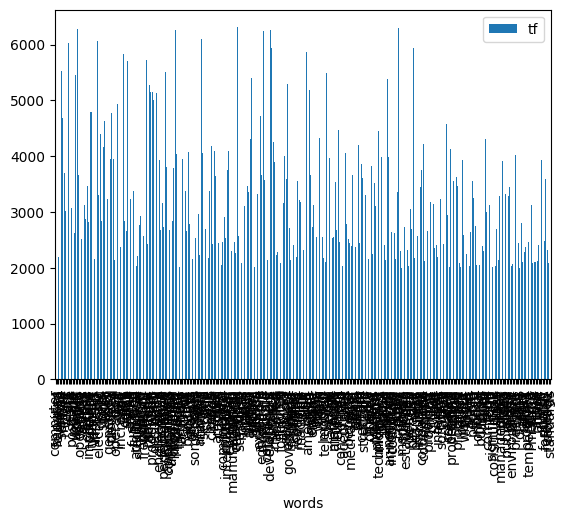

In [22]:
# Barplot

import matplotlib.pyplot as plt
tf_df = wiki_df["text_without_rare"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()
tf_df.columns = ["words", "tf"]
tf_df[tf_df["tf"] > 2000].plot.bar(x="words", y="tf")
plt.show()




C:\Users\anant\AppData\Local\Temp\ipykernel_572\720927070.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tf_df = wiki_df["text_without_rare"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()
C:\Users\anant\AppData\Local\Temp\ipykernel_572\720927070.py:1: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  tf_df = wiki_df["text_without_rare"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()
C:\Users\anant\AppData\Local\Temp\ipykernel_572\720927070.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tf_df = wiki_df["text_without_rare"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()
C:\Users\anant\AppData\Local\Temp\ipykernel_572\720

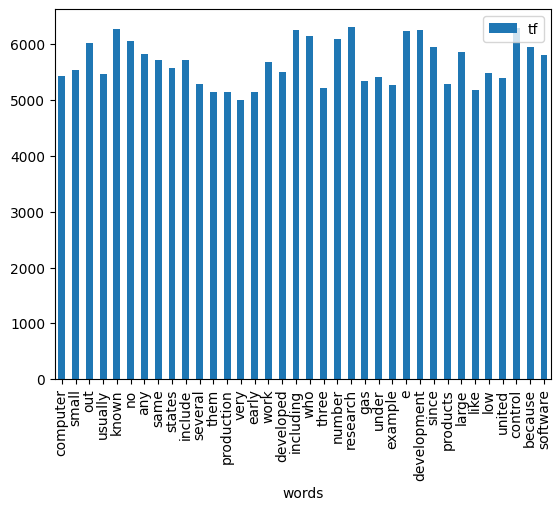

In [23]:
tf_df = wiki_df["text_without_rare"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()
tf_df.columns = ["words", "tf"]
tf_df[tf_df["tf"] > 5000].plot.bar(x="words", y="tf")
plt.show()

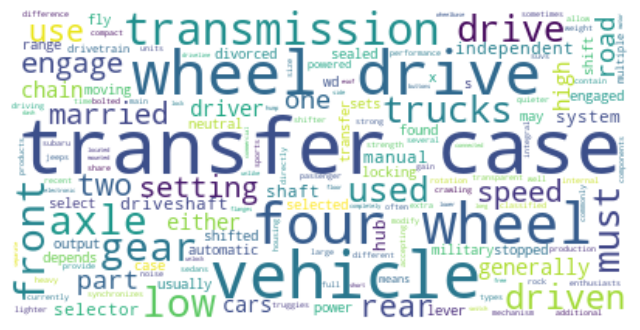

In [25]:
# Create a wordcloud

from wordcloud import WordCloud

txt = " ".join(i for i in wiki_df["text_without_rare"])
wordcloud = WordCloud(max_font_size=50, max_words=500, background_color="white").generate(text)

plt.figure(figsize=(8,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()